In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
import os
import json
from tqdm import tqdm
import copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


In [2]:
# Rebuilding the exact same architecture from notebook 01.
def build_resnet18_cifar():
    model = models.resnet18(weights=None)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(512, 10)
    return model

model_original = build_resnet18_cifar()
model_original.load_state_dict(
    torch.load('../checkpoints/resnet18_cifar10_best.pth', map_location=device)
)
model_original = model_original.to(device)
model_original.eval()
print("Original model loaded.")

Original model loaded.


In [3]:
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2023, 0.1994, 0.2010)

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test
)
test_subset = torch.utils.data.Subset(testset, range(2000))
testloader  = torch.utils.data.DataLoader(
    test_subset, batch_size=256, shuffle=False, num_workers=0
)

def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

baseline_acc = evaluate(model_original, testloader, device)
print(f"Baseline accuracy (for sanity check): {baseline_acc:.2f}%")

100%|██████████| 170M/170M [00:46<00:00, 3.65MB/s] 
d:\experimenting\compression-representation-analysis\venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Baseline accuracy (for sanity check): 90.15%


In [4]:
# Magnitude pruning is the method Han et al. (2016)
# introduced in Deep Compression.

# We test three sparsity levels: 30%, 50%, 70%.
# These are the same levels used in the compression literature
# as "mild", "moderate", and "aggressive" pruning.

import torch.nn.utils.prune as prune

def apply_global_magnitude_pruning(model, sparsity):
    """
    Applies unstructured global magnitude pruning across all Conv2d 
    and Linear layers at the given sparsity ratio.
    
    Global pruning sets a single threshold across all layers rather 
    than pruning each layer independently - Han et al. showed this 
    preserves accuracy better since some layers are more sensitive 
    than others.
    """
    # Collect all conv and linear weight tensors
    parameters_to_prune = []
    for module in model.modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            parameters_to_prune.append((module, 'weight'))

    prune.global_unstructured(
        parameters_to_prune,
        pruning_method=prune.L1Unstructured,
        amount=sparsity,
    )
    return model

def get_sparsity(model):
    """Returns the fraction of zero weights across all Conv2d and Linear layers."""
    total, zeros = 0, 0
    for module in model.modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            total += module.weight.nelement()
            zeros += (module.weight == 0).sum().item()
    return zeros / total

pruned_models = {}
pruning_results = {}

for sparsity in [0.3, 0.5, 0.7]:
    # deep copy so each model starts from the same trained baseline
    m = copy.deepcopy(model_original)
    m = apply_global_magnitude_pruning(m, sparsity)

    actual_sparsity = get_sparsity(m)
    acc = evaluate(m, testloader, device)

    label = f"pruned_{int(sparsity*100)}"
    pruned_models[label] = m
    pruning_results[label] = {
        "target_sparsity": sparsity,
        "actual_sparsity": round(actual_sparsity, 4),
        "accuracy": round(acc, 2)
    }
    print(f"Sparsity {int(sparsity*100)}% | Actual: {actual_sparsity:.3f} | Acc: {acc:.2f}%")

Sparsity 30% | Actual: 0.300 | Acc: 90.25%
Sparsity 50% | Actual: 0.500 | Acc: 90.05%
Sparsity 70% | Actual: 0.700 | Acc: 88.70%


In [5]:
from torch.quantization import quantize_dynamic

# Quantisation reduces weight precision from float32 (4 bytes) to int8 (1 byte).
# This is how models run on edge hardware — phones, car ECUs, embedded sensors.
# Post-training dynamic quantisation requires no retraining or calibration data,
# making it the most practical compression method for deployment.

model_quantised = copy.deepcopy(model_original).to('cpu')

model_quantised = quantize_dynamic(
    model_quantised,
    {nn.Linear, nn.Conv2d},
    dtype=torch.qint8
)

testloader_cpu = torch.utils.data.DataLoader(
    test_subset, batch_size=256, shuffle=False, num_workers=0
)

acc_quantised = evaluate(model_quantised, testloader_cpu, 'cpu')

def get_model_size_mb(model, quantised=False):
    bytes_per_param = 1 if quantised else 4
    total_bytes = sum(p.nelement() * bytes_per_param for p in model.parameters())
    return total_bytes / 1024**2

size_original  = get_model_size_mb(model_original,  quantised=False)
size_quantised = get_model_size_mb(model_quantised, quantised=True)

print(f"Original size:      {size_original:.1f} MB")
print(f"Quantised size:     {size_quantised:.1f} MB")
print(f"Compression ratio:  {size_original / size_quantised:.1f}x")
print(f"Quantised accuracy: {acc_quantised:.2f}%")

C:\Users\naeva\AppData\Local\Temp\ipykernel_23560\903135592.py:10: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_quantised = quantize_dynamic(


Original size:      42.6 MB
Quantised size:     10.7 MB
Compression ratio:  4.0x
Quantised accuracy: 90.15%


In [9]:
os.makedirs('../results/tables', exist_ok=True)
os.makedirs('../checkpoints', exist_ok=True)

# Save pruned model weights for use in notebooks 03 and 04.
# Quantised model is saved separately - it has a different internal 
# structure and can't be loaded back into a standard ResNet-18.
for label, m in pruned_models.items():
    torch.save(m.state_dict(), f'../checkpoints/{label}.pth')
    print(f"Saved: checkpoints/{label}.pth")

torch.save(model_quantised.state_dict(), '../checkpoints/quantised_int8.pth')
print("Saved: checkpoints/quantised_int8.pth")

# This becomes Table 1 in the final writeup.
# The accuracy numbers here are what we'll compare against CKA scores in notebook 03.
# The key question: does representational similarity follow the same trend as accuracy?
results = {
    "original": {
        "accuracy": round(baseline_acc, 2),
        "size_mb": round(size_original, 2),
        "sparsity": 0.0
    },
    **pruning_results,
    "quantised_int8": {
        "accuracy": round(acc_quantised, 2),
        "size_mb": round(size_quantised, 2),
    }
}

with open('../results/tables/compression_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("\ncompression_results.json:")
print(json.dumps(results, indent=2))

Saved: checkpoints/pruned_30.pth
Saved: checkpoints/pruned_50.pth
Saved: checkpoints/pruned_70.pth
Saved: checkpoints/quantised_int8.pth

compression_results.json:
{
  "original": {
    "accuracy": 90.15,
    "size_mb": 42.63,
    "sparsity": 0.0
  },
  "pruned_30": {
    "target_sparsity": 0.3,
    "actual_sparsity": 0.3,
    "accuracy": 90.25
  },
  "pruned_50": {
    "target_sparsity": 0.5,
    "actual_sparsity": 0.5,
    "accuracy": 90.05
  },
  "pruned_70": {
    "target_sparsity": 0.7,
    "actual_sparsity": 0.7,
    "accuracy": 88.7
  },
  "quantised_int8": {
    "accuracy": 90.15,
    "size_mb": 10.65
  }
}


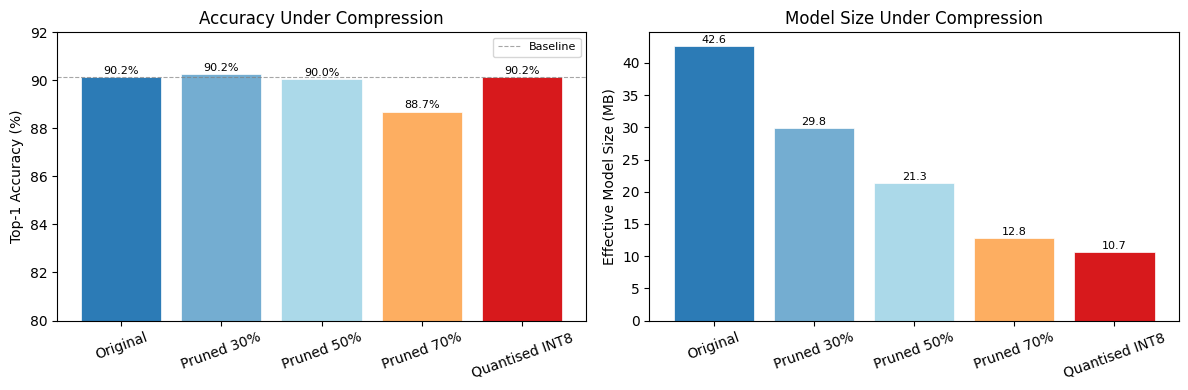

Saved: ../results/figures/compression_accuracy_size.png


In [10]:
import matplotlib.pyplot as plt

labels   = ['Original', 'Pruned 30%', 'Pruned 50%', 'Pruned 70%', 'Quantised INT8']
accuracy = [
    results['original']['accuracy'],
    results['pruned_30']['accuracy'],
    results['pruned_50']['accuracy'],
    results['pruned_70']['accuracy'],
    results['quantised_int8']['accuracy']
]
sizes = [
    results['original']['size_mb'],
    # Pruned models still store float32 weights - sparsity doesn't reduce 
    # storage unless you use sparse tensor formats. We report the effective
    # non-zero parameter size to be honest about what unstructured pruning 
    # actually achieves in practice.
    size_original * (1 - 0.30),
    size_original * (1 - 0.50),
    size_original * (1 - 0.70),
    results['quantised_int8']['size_mb']
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: accuracy bar chart
colors = ['#2c7bb6', '#74add1', '#abd9e9', '#fdae61', '#d7191c']
bars = axes[0].bar(labels, accuracy, color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_ylabel('Top-1 Accuracy (%)')
axes[0].set_title('Accuracy Under Compression')
axes[0].set_ylim(80, 92)
axes[0].axhline(y=results['original']['accuracy'], color='gray',
                linestyle='--', linewidth=0.8, alpha=0.7, label='Baseline')
axes[0].legend(fontsize=8)
axes[0].tick_params(axis='x', rotation=20)
for bar, acc in zip(bars, accuracy):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{acc:.1f}%', ha='center', va='bottom', fontsize=8)

# Right: model size bar chart
bars2 = axes[1].bar(labels, sizes, color=colors, edgecolor='white', linewidth=0.5)
axes[1].set_ylabel('Effective Model Size (MB)')
axes[1].set_title('Model Size Under Compression')
axes[1].tick_params(axis='x', rotation=20)
for bar, size in zip(bars2, sizes):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{size:.1f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
os.makedirs('../results/figures', exist_ok=True)
plt.savefig('../results/figures/compression_accuracy_size.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ../results/figures/compression_accuracy_size.png")